Loaded 33 calibration spectra with 7467 features each.
Interpolated YH_2025_007_DEE.csv to 7467 points
Interpolated YH_2025_007_DMSO.csv to 7467 points
Interpolated YH_2025_007_IPA.csv to 7467 points
Interpolated YH_2025_007_Water.csv to 7467 points
Loaded 4 solvent spectra.

Generating Gaussian synthetic calibration data for YH_2025_007_DEE...
Generating Gaussian synthetic calibration data for YH_2025_007_DMSO...
Generating Gaussian synthetic calibration data for YH_2025_007_IPA...
Generating Gaussian synthetic calibration data for YH_2025_007_Water...
Gaussian calibration dataset expanded to 429 samples.

Testing 12 files...

Prediction for YH_2025_009_DEE_A.CSV: y = 0.6066, MAE = 0.193353
Prediction for YH_2025_009_DEE_B.CSV: y = 0.7838, MAE = 0.016205
Prediction for YH_2025_009_DEE_C.CSV: y = 0.8177, MAE = 0.017730
Prediction for YH_2025_009_DMSO_A.CSV: y = 0.7787, MAE = 0.021301
Prediction for YH_2025_009_DMSO_B.CSV: y = 0.7909, MAE = 0.009083
Prediction for YH_2025_009_DMSO_C.CSV

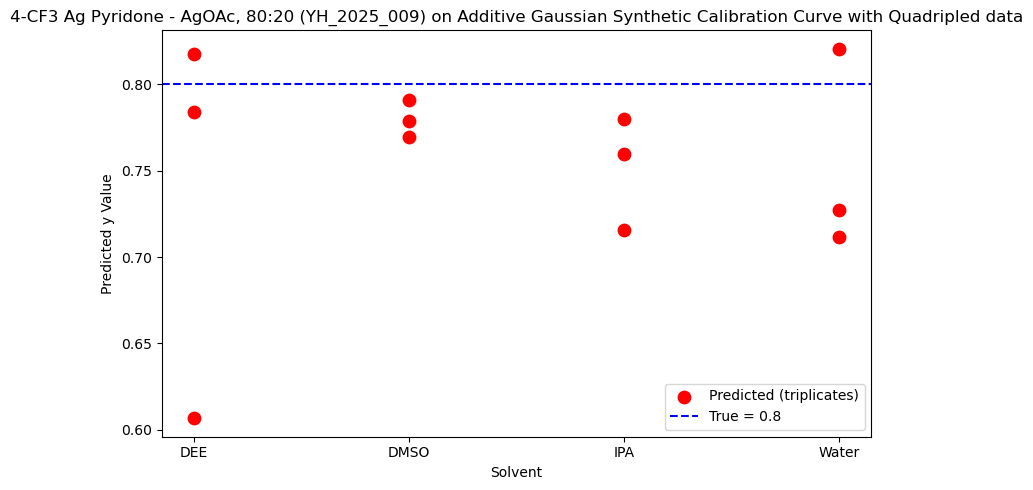


Triplicate-level results saved to YH_2025_009_gaussian_triplicates_results.csv


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

n_components = 5
true_y = 0.8
n_synthetic_per_solvent = 3

def load_spectrum(file_path):
    """Load 2nd column of CSV as spectrum."""
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    """Add solvent contamination (100% + α×solvent)."""
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating Gaussian synthetic calibration data for {solvent_name}...")
    for _ in range(n_synthetic_per_solvent):
        alpha = np.random.normal(loc=0.67, scale=0.05)
        alpha = max(0, min(alpha, 1.0)) 
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
print(f"Gaussian calibration dataset expanded to {len(X_calib_all)} samples.\n")

pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

predictions = []
maes = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((test_file, y_pred))
    maes.append(mae)
    
    print(f"Prediction for {test_file}: y = {y_pred:.4f}, MAE = {mae:.6f}")

print(f"\nAverage MAE across all test files: {np.mean(maes):.6f}")

solvent_labels = ['DEE', 'DMSO', 'IPA', 'Water']
x_positions = np.repeat(np.arange(len(solvent_labels)), 3)
y_values_plot = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values_plot, color='red', s=80, label='Predicted (triplicates)')
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True = {true_y}')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009) on Additive Gaussian Synthetic Calibration Curve with Quadripled data')
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})
results_df.to_csv('YH_2025_009_gaussian_triplicates_results.csv', index=False)
print("\nTriplicate-level results saved to YH_2025_009_gaussian_triplicates_results.csv")

Loaded 33 calibration spectra with 7467 features each.
Interpolated YH_2025_007_DEE.csv to 7467 points
Interpolated YH_2025_007_DMSO.csv to 7467 points
Interpolated YH_2025_007_IPA.csv to 7467 points
Interpolated YH_2025_007_Water.csv to 7467 points
Loaded 4 solvent spectra.

Generating Gaussian synthetic calibration data for YH_2025_007_DEE...
Generating Gaussian synthetic calibration data for YH_2025_007_DMSO...
Generating Gaussian synthetic calibration data for YH_2025_007_IPA...
Generating Gaussian synthetic calibration data for YH_2025_007_Water...
Gaussian calibration dataset expanded to 429 samples.

Testing 12 files...

Prediction for YH_2025_009_DEE_A.CSV: y = 0.6664, MAE = 0.133618
Prediction for YH_2025_009_DEE_B.CSV: y = 0.8382, MAE = 0.038225
Prediction for YH_2025_009_DEE_C.CSV: y = 0.8784, MAE = 0.078400
Prediction for YH_2025_009_DMSO_A.CSV: y = 0.8239, MAE = 0.023948
Prediction for YH_2025_009_DMSO_B.CSV: y = 0.8398, MAE = 0.039783
Prediction for YH_2025_009_DMSO_C.CSV

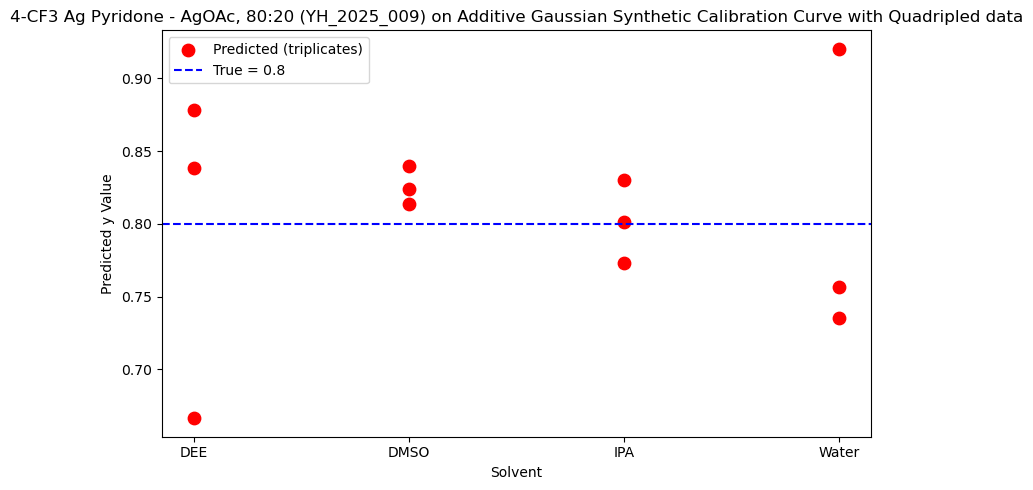


Triplicate-level results saved to YH_2025_009_gaussian_triplicates_results.csv


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

n_components = 5
true_y = 0.8
n_synthetic_per_solvent = 3

def load_spectrum(file_path):
    """Load 2nd column of CSV as spectrum."""
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    """Add solvent contamination (100% + α×solvent)."""
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating Gaussian synthetic calibration data for {solvent_name}...")
    for _ in range(n_synthetic_per_solvent):
        alpha = np.random.normal(loc=0.67, scale=0.05)
        alpha = max(0, min(alpha, 1.0)) 
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
print(f"Gaussian calibration dataset expanded to {len(X_calib_all)} samples.\n")

pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

predictions = []
maes = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((test_file, y_pred))
    maes.append(mae)
    
    print(f"Prediction for {test_file}: y = {y_pred:.4f}, MAE = {mae:.6f}")

print(f"\nAverage MAE across all test files: {np.mean(maes):.6f}")

solvent_labels = ['DEE', 'DMSO', 'IPA', 'Water']
x_positions = np.repeat(np.arange(len(solvent_labels)), 3)
y_values_plot = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values_plot, color='red', s=80, label='Predicted (triplicates)')
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True = {true_y}')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009) on Additive Gaussian Synthetic Calibration Curve with Quadripled data')
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})
results_df.to_csv('YH_2025_009_gaussian_triplicates_results.csv', index=False)
print("\nTriplicate-level results saved to YH_2025_009_gaussian_triplicates_results.csv")

Loaded 33 calibration spectra with 7468 features each.
Loaded 4 solvent spectra.

Generating Gaussian synthetic calibration data for YH_2025_007_DEE...
Generating Gaussian synthetic calibration data for YH_2025_007_DMSO...
Generating Gaussian synthetic calibration data for YH_2025_007_IPA...
Generating Gaussian synthetic calibration data for YH_2025_007_Water...
Gaussian calibration dataset expanded to 429 samples.

Testing 12 files...

Prediction for YH_2025_012_DEE_A.CSV: y = 0.4815, MAE = 0.318519
Prediction for YH_2025_012_DEE_B.CSV: y = 0.4801, MAE = 0.319865
Prediction for YH_2025_012_DEE_C.CSV: y = 0.4986, MAE = 0.301372
Prediction for YH_2025_012_DMSO_A.CSV: y = 0.5243, MAE = 0.275651
Prediction for YH_2025_012_DMSO_B.CSV: y = 0.4023, MAE = 0.397717
Prediction for YH_2025_012_DMSO_C.CSV: y = 0.4896, MAE = 0.310414
Prediction for YH_2025_012_IPA_A(real).CSV: y = 0.5547, MAE = 0.245295
Prediction for YH_2025_012_IPA_B(real).CSV: y = 0.5432, MAE = 0.256836
Prediction for YH_2025_0

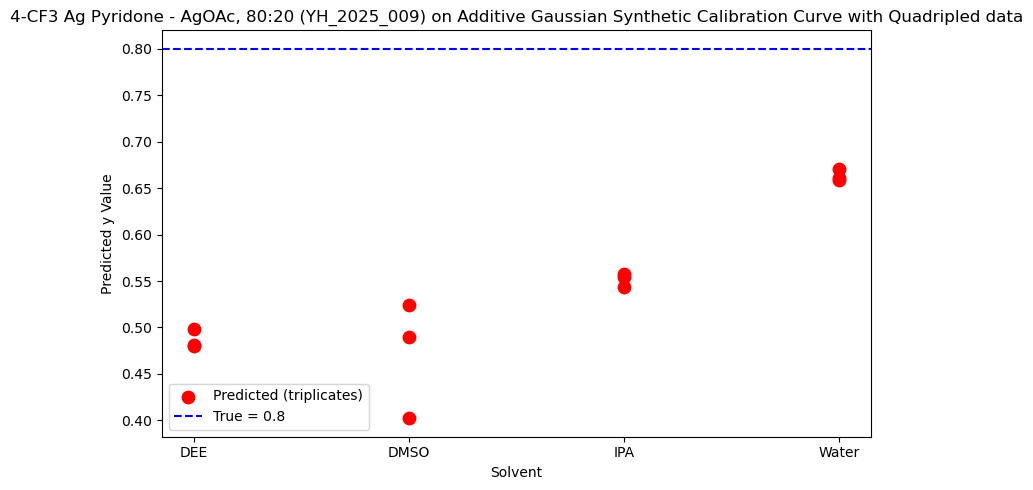


Triplicate-level results saved to YH_2025_009_gaussian_triplicates_results.csv


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'  
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_012/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

n_components = 5
true_y = 0.8
n_synthetic_per_solvent = 3

def load_spectrum(file_path):
    """Load 2nd column of CSV as spectrum."""
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    """Add solvent contamination (100% + α×solvent)."""
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating Gaussian synthetic calibration data for {solvent_name}...")
    for _ in range(n_synthetic_per_solvent):
        alpha = np.random.normal(loc=0.67, scale=0.05)
        alpha = max(0, min(alpha, 1.0)) 
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
print(f"Gaussian calibration dataset expanded to {len(X_calib_all)} samples.\n")

pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

predictions = []
maes = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((test_file, y_pred))
    maes.append(mae)
    
    print(f"Prediction for {test_file}: y = {y_pred:.4f}, MAE = {mae:.6f}")

print(f"\nAverage MAE across all test files: {np.mean(maes):.6f}")

solvent_labels = ['DEE', 'DMSO', 'IPA', 'Water']
x_positions = np.repeat(np.arange(len(solvent_labels)), 3)
y_values_plot = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values_plot, color='red', s=80, label='Predicted (triplicates)')
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True = {true_y}')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009) on Additive Gaussian Synthetic Calibration Curve with Quadripled data')
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})
results_df.to_csv('YH_2025_009_gaussian_triplicates_results.csv', index=False)
print("\nTriplicate-level results saved to YH_2025_009_gaussian_triplicates_results.csv")

In [4]:
import time
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

def evaluate_config(mean_alpha, std_alpha, n_synth, n_repeats=30, seed_base=0):
    """Repeat the synthetic-data -> train -> test pipeline n_repeats times.
       Return (mean_MAE, std_MAE). Uses deterministic RNG seeds derived from seed_base.
    """
    maes = []
    for repeat in range(n_repeats):
        rng = np.random.RandomState(seed_base + repeat)

        X_aug = [X_calib]
        y_aug = [y_calib]
        for solvent_spec in solvents.values():
            alphas = rng.normal(loc=mean_alpha, scale=std_alpha, size=n_synth)
            alphas = np.clip(alphas, 0.0, 1.0)
            for alpha in alphas:
                X_s = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
                X_aug.append(X_s)
                y_aug.append(y_calib)

        X_all = np.vstack(X_aug)
        y_all = np.concatenate(y_aug)

        pls_temp = PLSRegression(n_components=n_components)
        pls_temp.fit(X_all, y_all)
        temp_maes = []
        for test_file in test_files:
            test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
            y_pred = float(pls_temp.predict(test_spec.reshape(1, -1))[0])
            temp_maes.append(mean_absolute_error([true_y], [y_pred]))

        maes.append(np.mean(temp_maes))

    return float(np.mean(maes)), float(np.std(maes))

means = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6,0.7,0.8,0.9,1.0]         
stds  = [0.05, 0.10, 0.15]              
synth_counts = [3, 4, 6]               
n_repeats = 30                          
seed_base = 1234                         

results = []
start_time = time.time()
for mean_alpha in means:
    for std_alpha in stds:
        for n_synth in synth_counts:
            mean_mae, std_mae = evaluate_config(mean_alpha, std_alpha, n_synth,
                                                 n_repeats=n_repeats, seed_base=seed_base)
            results.append((mean_alpha, std_alpha, n_synth, mean_mae, std_mae))
            #print(f"mean={mean_alpha:.3f}, std={std_alpha:.3f}, synth={n_synth} -> "
                  #f"mean_MAE={mean_mae:.5f}, std_MAE={std_mae:.5f}")

results_sorted = sorted(results, key=lambda t: (t[3], t[4]))
best = results_sorted[0]
print("\nBEST CONFIG:", best)
elapsed = time.time() - start_time
print(f"Grid search done in {elapsed:.1f} s")

import pandas as pd
df = pd.DataFrame(results, columns=["mean","std","synth","mean_mae","std_mae"])
df.to_dict("records")


BEST CONFIG: (0.7, 0.05, 4, 0.04782247834912756, 0.004687869681892309)
Grid search done in 381.3 s


[{'mean': 0.1,
  'std': 0.05,
  'synth': 3,
  'mean_mae': 0.1092585669494907,
  'std_mae': 0.04578131802353295},
 {'mean': 0.1,
  'std': 0.05,
  'synth': 4,
  'mean_mae': 0.10945164809018594,
  'std_mae': 0.04008898501738815},
 {'mean': 0.1,
  'std': 0.05,
  'synth': 6,
  'mean_mae': 0.10276211895248036,
  'std_mae': 0.028354118921295687},
 {'mean': 0.1,
  'std': 0.1,
  'synth': 3,
  'mean_mae': 0.1323377218667679,
  'std_mae': 0.0681800874407032},
 {'mean': 0.1,
  'std': 0.1,
  'synth': 4,
  'mean_mae': 0.11925758094614099,
  'std_mae': 0.04732796195448828},
 {'mean': 0.1,
  'std': 0.1,
  'synth': 6,
  'mean_mae': 0.1312629776502782,
  'std_mae': 0.054752656278385485},
 {'mean': 0.1,
  'std': 0.15,
  'synth': 3,
  'mean_mae': 0.14249479994026545,
  'std_mae': 0.07370430309617387},
 {'mean': 0.1,
  'std': 0.15,
  'synth': 4,
  'mean_mae': 0.13562414295544364,
  'std_mae': 0.05810717542831923},
 {'mean': 0.1,
  'std': 0.15,
  'synth': 6,
  'mean_mae': 0.1421759166061176,
  'std_mae': 0.

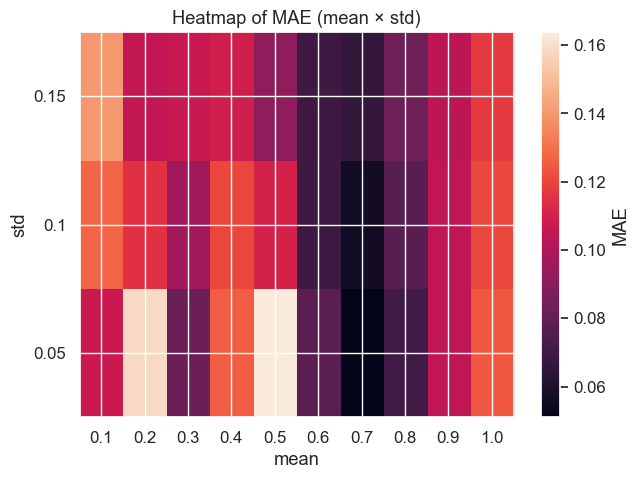

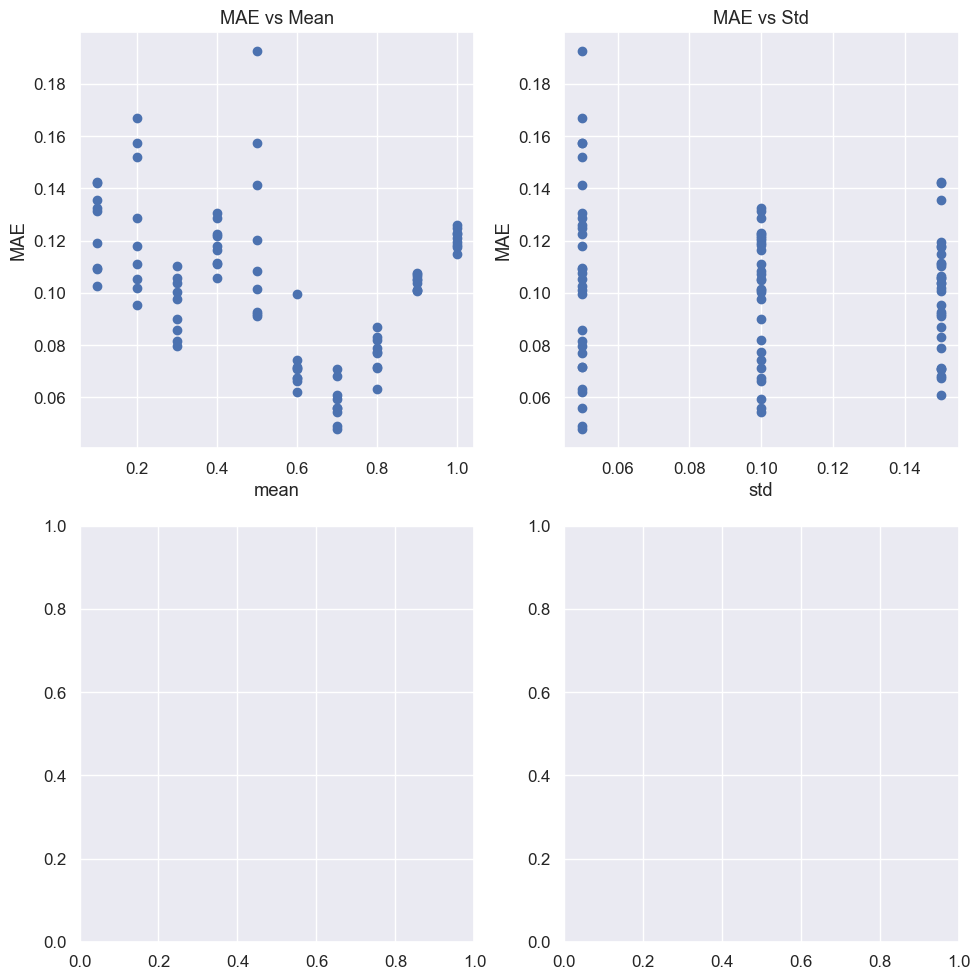

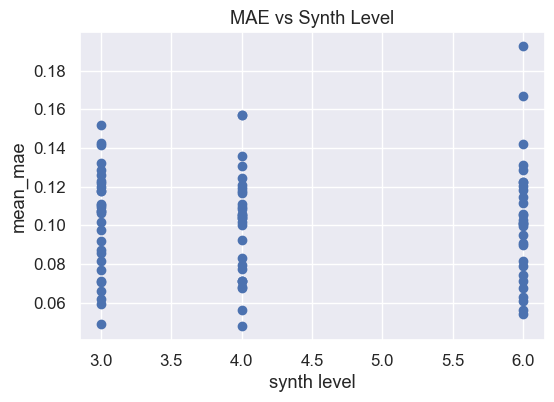

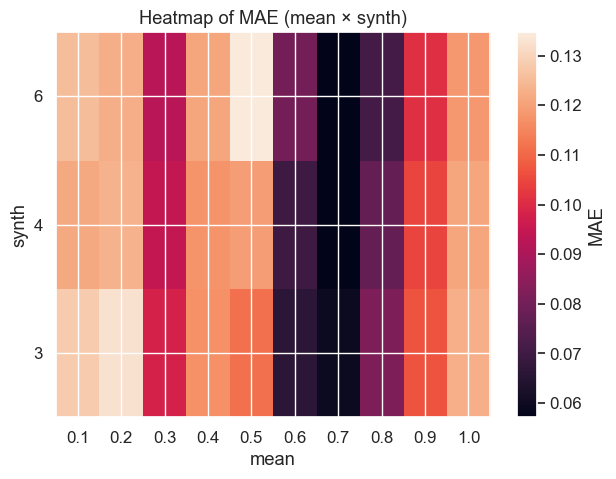

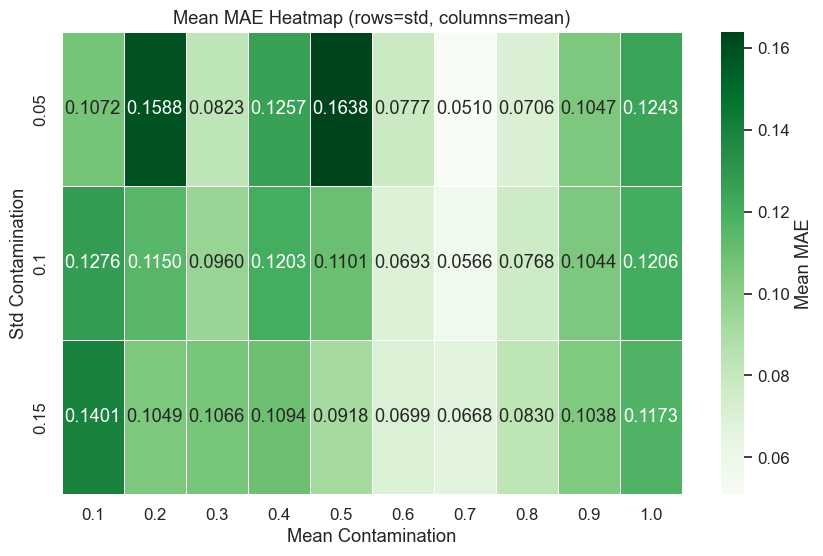

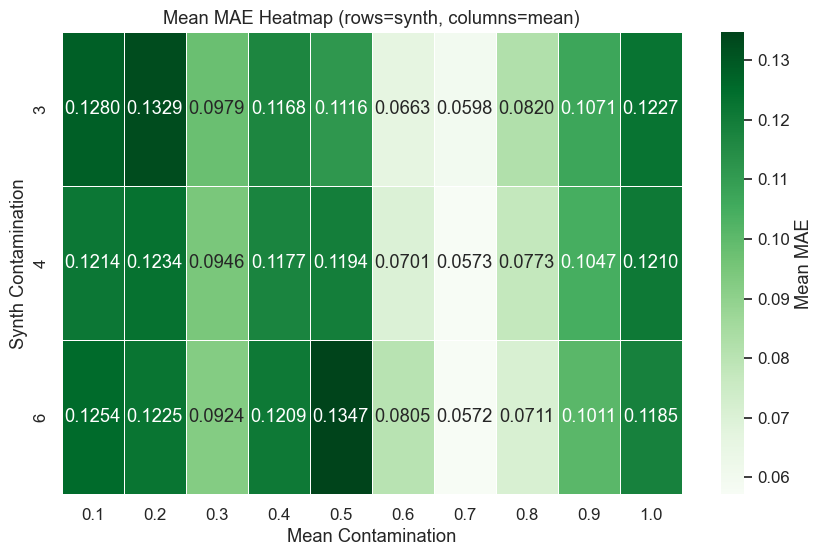

In [60]:
import matplotlib.pyplot as plt
import numpy as np

pivot = df.pivot_table(
    index="std",
    columns="mean",
    values="mean_mae"
)

plt.figure(figsize=(7,5))
plt.imshow(pivot, aspect='auto', origin='lower')
plt.xticks(range(len(pivot.columns)), pivot.columns.round(2))
plt.yticks(range(len(pivot.index)), pivot.index.round(2))
plt.xlabel("mean")
plt.ylabel("std")
plt.title("Heatmap of MAE (mean × std)")
plt.colorbar(label="MAE")
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(10,10))

axs[0,0].scatter(df["mean"], df["mean_mae"])
axs[0,0].set_title("MAE vs Mean")
axs[0,0].set_xlabel("mean")
axs[0,0].set_ylabel("MAE")

axs[0,1].scatter(df["std"], df["mean_mae"])
axs[0,1].set_title("MAE vs Std")
axs[0,1].set_xlabel("std")
axs[0,1].set_ylabel("MAE")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["synth"], df["mean_mae"])
plt.xlabel("synth level")
plt.ylabel("mean_mae")
plt.title("MAE vs Synth Level")
plt.show()

import numpy as np

pivot = df.pivot_table(
    index="synth",
    columns="mean",
    values="mean_mae"
)
plt.figure(figsize=(7,5))
plt.imshow(pivot, aspect='auto', origin='lower')
plt.xticks(range(len(pivot.columns)), pivot.columns.round(2))
plt.yticks(range(len(pivot.index)), pivot.index.round(2))
plt.xlabel("mean")
plt.ylabel("synth")
plt.title("Heatmap of MAE (mean × synth)")
plt.colorbar(label="MAE")
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df.pivot_table(index='std', columns='mean', values='mean_mae', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.set(font_scale=1.1)
ax = sns.heatmap(
    heatmap_data,
    annot=True,            
    fmt=".4f",             
    cmap="Greens",       
    linewidths=0.5,
    cbar_kws={'label': 'Mean MAE'}
)

ax.set_title("Mean MAE Heatmap (rows=std, columns=mean)")
ax.set_xlabel("Mean Contamination")
ax.set_ylabel("Std Contamination")
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df.pivot_table(index='synth', columns='mean', values='mean_mae', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.set(font_scale=1.1)
ax = sns.heatmap(
    heatmap_data,
    annot=True,            
    fmt=".4f",             
    cmap="Greens",       
    linewidths=0.5,
    cbar_kws={'label': 'Mean MAE'}
)

ax.set_title("Mean MAE Heatmap (rows=synth, columns=mean)")
ax.set_xlabel("Mean Contamination")
ax.set_ylabel("Synth Contamination")
plt.show()

In [5]:
import time
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

def evaluate_config(mean_alpha, std_alpha, n_synth, n_repeats=30, seed_base=0):
    """Repeat the synthetic-data -> train -> test pipeline n_repeats times.
       Return (mean_MAE, std_MAE). Uses deterministic RNG seeds derived from seed_base.
    """
    maes = []
    for repeat in range(n_repeats):
        rng = np.random.RandomState(seed_base + repeat)

        X_aug = [X_calib]
        y_aug = [y_calib]
        for solvent_spec in solvents.values():
            alphas = rng.normal(loc=mean_alpha, scale=std_alpha, size=n_synth)
            alphas = np.clip(alphas, 0.0, 1.0)
            for alpha in alphas:
                X_s = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
                X_aug.append(X_s)
                y_aug.append(y_calib)

        X_all = np.vstack(X_aug)
        y_all = np.concatenate(y_aug)

        pls_temp = PLSRegression(n_components=n_components)
        pls_temp.fit(X_all, y_all)
        temp_maes = []
        for test_file in test_files:
            test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
            y_pred = float(pls_temp.predict(test_spec.reshape(1, -1))[0])
            temp_maes.append(mean_absolute_error([true_y], [y_pred]))

        maes.append(np.mean(temp_maes))

    return float(np.mean(maes)), float(np.std(maes))

means = [0.65, 0.66, 0.67, 0.68, 0.69,0.70,0.71,0.72,0.73,0.74,0.75]         
stds  = [0.05, 0.10, 0.15]              
synth_counts = [3, 4, 5, 6]               
n_repeats = 30                          
seed_base = 1234                         

results = []
start_time = time.time()
for mean_alpha in means:
    for std_alpha in stds:
        for n_synth in synth_counts:
            mean_mae, std_mae = evaluate_config(mean_alpha, std_alpha, n_synth,
                                                 n_repeats=n_repeats, seed_base=seed_base)
            results.append((mean_alpha, std_alpha, n_synth, mean_mae, std_mae))
            #print(f"mean={mean_alpha:.3f}, std={std_alpha:.3f}, synth={n_synth} -> "
                  #f"mean_MAE={mean_mae:.5f}, std_MAE={std_mae:.5f}")

results_sorted = sorted(results, key=lambda t: (t[3], t[4]))
best = results_sorted[0]
print("\nBEST CONFIG:", best)
elapsed = time.time() - start_time
print(f"Grid search done in {elapsed:.1f} s")

import pandas as pd
df = pd.DataFrame(results, columns=["mean","std","synth","mean_mae","std_mae"])
df.to_dict("records")


BEST CONFIG: (0.67, 0.05, 3, 0.047531301212919215, 0.005839773467348731)
Grid search done in 2917.5 s


[{'mean': 0.65,
  'std': 0.05,
  'synth': 3,
  'mean_mae': 0.048552212216388946,
  'std_mae': 0.008330490506813023},
 {'mean': 0.65,
  'std': 0.05,
  'synth': 4,
  'mean_mae': 0.05313967949159518,
  'std_mae': 0.01319876357295662},
 {'mean': 0.65,
  'std': 0.05,
  'synth': 5,
  'mean_mae': 0.05919242736920826,
  'std_mae': 0.016111900915743355},
 {'mean': 0.65,
  'std': 0.05,
  'synth': 6,
  'mean_mae': 0.07059578522335669,
  'std_mae': 0.01884317629789128},
 {'mean': 0.65,
  'std': 0.1,
  'synth': 3,
  'mean_mae': 0.058427728518405844,
  'std_mae': 0.01718979503840926},
 {'mean': 0.65,
  'std': 0.1,
  'synth': 4,
  'mean_mae': 0.05828776769933448,
  'std_mae': 0.018075139963325583},
 {'mean': 0.65,
  'std': 0.1,
  'synth': 5,
  'mean_mae': 0.05575628030012155,
  'std_mae': 0.018058012859508983},
 {'mean': 0.65,
  'std': 0.1,
  'synth': 6,
  'mean_mae': 0.06046338194647627,
  'std_mae': 0.01697298010426551},
 {'mean': 0.65,
  'std': 0.15,
  'synth': 3,
  'mean_mae': 0.06764444267237799

Loaded CF3 pure spectra (7468 features)
Loaded 4 solvent spectra
Synthetic calibration size: 2904
YH_2025_009_DEE_A.CSV: y = 0.9472, MAE = 0.1472
YH_2025_009_DEE_B.CSV: y = 0.9599, MAE = 0.1599
YH_2025_009_DEE_C.CSV: y = 1.0059, MAE = 0.2059
YH_2025_009_DMSO_A.CSV: y = 0.8877, MAE = 0.0877
YH_2025_009_DMSO_B.CSV: y = 0.8931, MAE = 0.0931
YH_2025_009_DMSO_C.CSV: y = 0.8722, MAE = 0.0722
YH_2025_009_IPA_A.CSV: y = 0.9478, MAE = 0.1478
YH_2025_009_IPA_B.CSV: y = 0.8756, MAE = 0.0756
YH_2025_009_IPA_C.CSV: y = 0.9142, MAE = 0.1142
YH_2025_009_Water_A.CSV: y = 0.8462, MAE = 0.0462
YH_2025_009_Water_B.CSV: y = 0.8607, MAE = 0.0607
YH_2025_009_Water_C.CSV: y = 1.0910, MAE = 0.2910

Average MAE: 0.1251


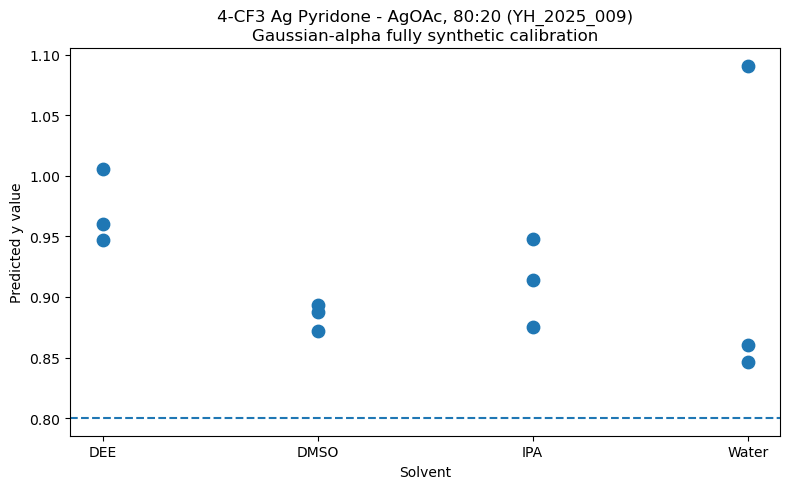

In [2]:
#Gaussian
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

fractions    = np.linspace(0.4, 1.2, 121)
n_components = 5
true_y       = 0.8

# Gaussian alpha
n_synthetic_per_frac = 6
alpha_mu    = 0.17
alpha_sigma = 0.03

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)

cf3_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_cf3 = np.array([
    load_spectrum(os.path.join(pure_dir, f))
    for f in cf3_files
])

n_features = min(len(s) for s in pure_cf3)
pure_cf3 = pure_cf3[:, :n_features]

pure_cf3 = np.array([normalize(s) for s in pure_cf3])
pure_cf3 = np.array([savgol(s) for s in pure_cf3])

pure_mean = pure_cf3.mean(axis=0)

print(f"Loaded CF3 pure spectra ({n_features} features)")

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))

    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )

    s = normalize(s)
    s = savgol(s)

    solvents.append(s)

solvents = np.array(solvents)

print(f"Loaded {len(solvents)} solvent spectra")

X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for _ in range(n_synthetic_per_frac):

            alpha = rng.normal(alpha_mu, alpha_sigma)
            alpha = np.clip(alpha, 0.0, 1.0)

            ref = pure_cf3[rng.integers(len(pure_cf3))]
            delta = frac * (ref - pure_mean)

            synthetic = solvent + alpha * delta

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration size: {len(X_cal)}")

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

test_files = sorted(
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
)

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = normalize(s)
    s = savgol(s)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = ['DEE', 'DMSO', 'IPA', 'Water']
x = np.repeat(np.arange(len(labels)), 3)
y_plot = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x, y_plot, s=80)
plt.axhline(true_y, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009)\nGaussian-alpha fully synthetic calibration')
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})


Loaded Alpha + AgOAc spectra (7468 features)
Loaded 4 solvent spectra
Synthetic calibration set size: 2904 samples × 7468 features
YH_2025_009_DEE_A.CSV: y=0.7962, MAE=0.0038
YH_2025_009_DEE_B.CSV: y=0.7948, MAE=0.0052
YH_2025_009_DEE_C.CSV: y=0.7943, MAE=0.0057
YH_2025_009_DMSO_A.CSV: y=0.7989, MAE=0.0011
YH_2025_009_DMSO_B.CSV: y=0.7971, MAE=0.0029
YH_2025_009_DMSO_C.CSV: y=0.8076, MAE=0.0076
YH_2025_009_IPA_A.CSV: y=0.7994, MAE=0.0006
YH_2025_009_IPA_B.CSV: y=0.7976, MAE=0.0024
YH_2025_009_IPA_C.CSV: y=0.7957, MAE=0.0043
YH_2025_009_Water_A.CSV: y=0.8004, MAE=0.0004
YH_2025_009_Water_B.CSV: y=0.8006, MAE=0.0006
YH_2025_009_Water_C.CSV: y=0.8162, MAE=0.0162

Average MAE: 0.0042


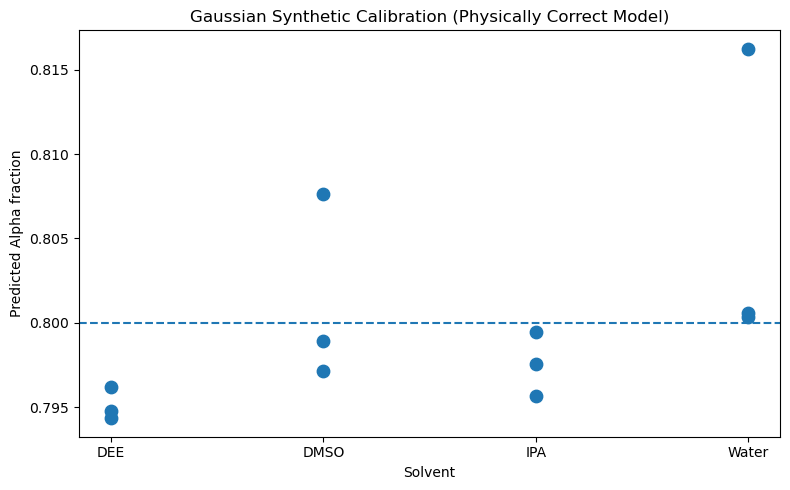

In [20]:
# ------------------ IMPORTS ------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

# ------------------ PATHS ------------------
pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

# ------------------ SETTINGS ------------------
fractions = np.linspace(0.0, 1.2, 121)
n_components = 5
true_fraction_alpha = 0.8

# Gaussian contamination (KEY CHANGE)
n_synthetic_per_frac = 6
alpha_mu = 0.17
alpha_sigma = 0.03

# ------------------ FUNCTIONS ------------------
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)

def synthesize_mix(alpha_spec, ag_spec, frac):
    return frac * alpha_spec + (1 - frac) * ag_spec

# ------------------ LOAD PURE SPECTRA ------------------
alpha_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

ag_files = [
    'YH_2025_010_AgOAC_A.CSV',
    'YH_2025_010_AgOAC_B.CSV',
    'YH_2025_010_AgOAC_C.CSV'
]

alpha_specs = np.array([
    savgol(normalize(load_spectrum(os.path.join(pure_dir, f))))
    for f in alpha_files
])

ag_specs = np.array([
    savgol(normalize(load_spectrum(os.path.join(pure_dir, f))))
    for f in ag_files
])

# match feature length
n_features = min(alpha_specs.shape[1], ag_specs.shape[1])
alpha_specs = alpha_specs[:, :n_features]
ag_specs = ag_specs[:, :n_features]

print(f"Loaded Alpha + AgOAc spectra ({n_features} features)")

# ------------------ LOAD SOLVENTS ------------------
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))

    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )

    s = savgol(normalize(s))
    solvents.append(s)

solvents = np.array(solvents)
print(f"Loaded {len(solvents)} solvent spectra")

# ------------------ SYNTHETIC CALIBRATION ------------------
X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for _ in range(n_synthetic_per_frac):

            # Gaussian contamination
            alpha_val = rng.normal(alpha_mu, alpha_sigma)
            alpha_val = np.clip(alpha_val, 0.0, 1.0)

            # randomly choose real spectra
            alpha_spec = alpha_specs[rng.integers(len(alpha_specs))]
            ag_spec    = ag_specs[rng.integers(len(ag_specs))]

            # build mixture
            mix = synthesize_mix(alpha_spec, ag_spec, frac)

            # add solvent contamination
            synthetic = (mix + alpha_val * solvent) / (1 + alpha_val)

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration set size: {X_cal.shape[0]} samples × {X_cal.shape[1]} features")

# ------------------ SCALE ------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cal)

# ------------------ MODEL ------------------
pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled, y_cal)

# ------------------ TEST ------------------
test_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
])

labels = ['DEE','DMSO','IPA','Water']
predictions, maes = [], []

for f in test_files:

    # build real 80:20 mixture from real spectra
    alpha_spec = alpha_specs[rng.integers(len(alpha_specs))]
    ag_spec    = ag_specs[rng.integers(len(ag_specs))]
    s_test = synthesize_mix(alpha_spec, ag_spec, true_fraction_alpha)

    # match solvent from filename
    for i, sol in enumerate(labels):
        if sol in f:
            solvent = solvents[i]
            break

    # apply SAME Gaussian contamination (IMPORTANT)
    alpha_val = np.clip(rng.normal(alpha_mu, alpha_sigma), 0, 1)
    s_test = (s_test + alpha_val * solvent) / (1 + alpha_val)

    # predict
    s_scaled = scaler.transform(s_test.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_fraction_alpha], [y_pred])

    predictions.append((f, y_pred))
    maes.append(mae)

    print(f"{f}: y={y_pred:.4f}, MAE={mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

# ------------------ PLOT ------------------
x = np.repeat(np.arange(len(labels)), 3)
y_plot = [p[1] for p in predictions]

plt.figure(figsize=(8,5))
plt.scatter(x, y_plot, s=80)
plt.axhline(true_fraction_alpha, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted Alpha fraction')
plt.title('Gaussian Synthetic Calibration (Physically Correct Model)')
plt.tight_layout()
plt.show()

# ------------------ SAVE ------------------
df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from scipy.signal import savgol_filter

# ------------------ PATHS ------------------
pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'

# ------------------ SETTINGS ------------------
fractions = np.linspace(0.0, 1.2, 121)
n_components = 5
n_splits = 5

# Gaussian params
n_synthetic_per_frac = 6
alpha_mu = 0.17
alpha_sigma = 0.03

# ------------------ FUNCTIONS ------------------
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)

def synthesize_mix(alpha_spec, ag_spec, frac):
    return frac * alpha_spec + (1 - frac) * ag_spec

# ------------------ LOAD PURE ------------------
alpha_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

ag_files = [
    'YH_2025_010_AgOAC_A.CSV',
    'YH_2025_010_AgOAC_B.CSV',
    'YH_2025_010_AgOAC_C.CSV'
]

alpha_specs = np.array([
    savgol(normalize(load_spectrum(os.path.join(pure_dir, f))))
    for f in alpha_files
])

ag_specs = np.array([
    savgol(normalize(load_spectrum(os.path.join(pure_dir, f))))
    for f in ag_files
])

n_features = min(alpha_specs.shape[1], ag_specs.shape[1])
alpha_specs = alpha_specs[:, :n_features]
ag_specs = ag_specs[:, :n_features]

print(f"Loaded Alpha + AgOAc spectra ({n_features} features)")

# ------------------ LOAD SOLVENTS ------------------
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))

    if len(s) != n_features:
        s = np.interp(
            np.linspace(0,1,n_features),
            np.linspace(0,1,len(s)),
            s
        )

    s = savgol(normalize(s))
    solvents.append(s)

solvents = np.array(solvents)
print(f"Loaded {len(solvents)} solvent spectra")

# ------------------ SYNTHETIC + GROUPS ------------------
X_cal, y_cal, groups = [], [], []

rng = np.random.default_rng(42)
group_id = 0

for solvent_idx, solvent in enumerate(solvents):
    for frac in fractions:

        # ONE group = same solvent + same fraction
        for _ in range(n_synthetic_per_frac):

            alpha_val = np.clip(rng.normal(alpha_mu, alpha_sigma), 0, 1)

            alpha_spec = alpha_specs[rng.integers(len(alpha_specs))]
            ag_spec    = ag_specs[rng.integers(len(ag_specs))]

            mix = synthesize_mix(alpha_spec, ag_spec, frac)
            synthetic = (mix + alpha_val * solvent) / (1 + alpha_val)

            X_cal.append(synthetic)
            y_cal.append(frac)
            groups.append(group_id)

        group_id += 1

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
groups = np.array(groups)

print(f"Synthetic dataset: {X_cal.shape[0]} samples")
print(f"Total groups: {len(np.unique(groups))}")

# ------------------ GROUP K-FOLD ------------------
gkf = GroupKFold(n_splits=n_splits)

mae_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_cal, y_cal, groups)):
    print(f"\nFold {fold+1}")

    X_train, X_test = X_cal[train_idx], X_cal[test_idx]
    y_train, y_test = y_cal[train_idx], y_cal[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train_scaled, y_train)

    y_pred = pls.predict(X_test_scaled).ravel()
    mae = mean_absolute_error(y_test, y_pred)

    mae_scores.append(mae)
    print(f"MAE: {mae:.4f}")

print("\n========================")
print(f"CV MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print("========================")

Loaded Alpha + AgOAc spectra (7468 features)
Loaded 4 solvent spectra
Synthetic dataset: 2904 samples
Total groups: 484

Fold 1
MAE: 0.0064

Fold 2
MAE: 0.0062

Fold 3
MAE: 0.0058

Fold 4
MAE: 0.0061

Fold 5
MAE: 0.0060

CV MAE: 0.0061 ± 0.0002
